
Parent directory: /home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


In [33]:
import os
parent = os.path.dirname(os.getcwd())
print("Parent directory:", parent)
import numpy as np
import pandas as pd
import os, sys
from pyLIMA import event
from scipy.signal import find_peaks
from tqdm.auto import tqdm
from pyLIMA import telescopes
from pyLIMA.models import USBL_model
from astropy.time import Time
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.table import QTable
from astropy.time import Time
from astropy.coordinates import SkyCoord

import copy
from pathlib import Path
# script_dir = Path(__file__).parent
import sys
script_dir=parent
sys.path.append(script_dir)
sys.path.append(script_dir+'/photutils/')


from pyLIMA import event
from pyLIMA import telescopes
from pyLIMA.toolbox import time_series
from pyLIMA.simulations import simulator
from pyLIMA.models import PSBL_model
from pyLIMA.models import USBL_model
from pyLIMA.models import FSPLarge_model
from pyLIMA.models import PSPL_model
from pyLIMA.fits import TRF_fit
from pyLIMA.fits import DE_fit
from pyLIMA.fits import MCMC_fit
from pyLIMA.outputs import pyLIMA_plots
from pyLIMA.outputs import file_outputs

Parent directory: /home/karennowo/microlensing/simulation_Rubin/roman_rubin


In [34]:
ZP = {'W149':27.615, 'u':27.03, 'g':28.38, 'r':28.16,
          'i':27.85, 'z':27.46, 'y':26.68}

def rubin_telescope(rubin_ts):
    lsst_filterlist = 'ugrizy'
    dict_tels = {}
    for band in rubin_ts:
        dict_tels[band] = telescopes.Telescope(name=band, camera_filter=band, location='Earth',
                                              lightcurve=rubin_ts[band],
                                              lightcurve_names=['time', 'mag', 'err_mag'],
                                              lightcurve_units=['JD', 'mag', 'mag'])
    return dict_tels


def Event_rubin_dp0(name,ra,dec, ts_dict):
    '''
    This function creates an Event from pyLIMA
    
    ts_dict (dict): keys 'u','g','r','i','z','y'
    l (float): galactic coordinate l
    b (float): galactic coordinate b
    '''
    my_own_creation = event.Event(ra=ra, dec=dec)
    my_own_creation.name = name
    lsst_filterlist = 'ugrizy'
    rubin_ts = {}
    for band in lsst_filterlist:
        if band in ts_dict.keys():
            mjd = ts_dict[band]
            m5 = np.ones(len(mjd))*20
            int_array = np.column_stack((mjd, m5, m5)).astype(float)
            rubin_ts[band] = int_array
        
    for band in lsst_filterlist:
        if band in ts_dict.keys():
            my_own_creation.telescopes.append(rubin_telescope(rubin_ts)[band])

    return my_own_creation


def sim_lightcurve(i, data, event, model, magstar, parallax):
    '''
    i (int): index of the TRILEGAL data set
    data (dictionary): parameters including magnitude of the stars
    path_ephemerides (str): path to the ephemeris of Gaia
    path_dataslice(str): path to the dataslice obtained from OpSims
    model(str): model desired
    '''
    # magstar = {'W149': data["W149"], 'u': data["u"], 'g': data["g"], 'r': data["r"],
    #            'i': data["i"], 'z': data["z"], 'y': data["Y"]}
    ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
          'i': 27.85, 'z': 27.46, 'y': 26.68}

    
    new_creation = copy.deepcopy(event)
    np.random.seed(i)
    t0 = data['t0']
    tE = data['tE']

    if model == 'USBL':
        params = {'t0': data['t0'], 'u0': data['u0'], 'tE': data['tE'], 'rho': data['rho'],
                  's': data['s'], 'q': data['q'], 'alpha': data['alpha'],
                  'piEN': data['piEN'], 'piEE': data['piEE']}
        choice = np.random.choice(["central_caustic", "second_caustic", "third_caustic"])
        # usbl = pyLIMA.models.USBL_model.USBLmodel(roman_event, origin=[choice, [0, 0]],blend_flux_parameter='ftotal')
        my_own_model = USBL_model.USBLmodel(new_creation, origin=[choice, [0, 0]],
                                            blend_flux_parameter='ftotal',
                                            parallax=['Full', t0] if parallax else ['None', 0.0])
        print(my_own_model.origin)
        # my_own_model = USBL_model.USBLmodel(new_creation,origin=[choice, [0, 0]], parallax=['Full', t0])
    elif model == 'FSPL':
        params = {'t0': data['t0'], 'u0': data['u0'], 'tE': data['tE'],
                  'rho': data['rho'], 'piEN': data['piEN'],
                  'piEE': data['piEE']}
        my_own_model = FSPLarge_model.FSPLargemodel(new_creation, parallax=['Full', t0] if parallax else ['None', 0.0])
    elif model == 'PSPL':
        params = {'t0': data['t0'], 'u0': data['u0'], 'tE': data['tE'],
                  'piEN': data['piEN'], 'piEE': data['piEE']}
        my_own_model = PSPL_model.PSPLmodel(new_creation, parallax=['Full', t0] if parallax else ['None', 0.0])

    my_own_parameters = []
    for key in params:
        my_own_parameters.append(params[key])

    my_own_flux_parameters = []
    fs, G, F = {}, {}, {}
    np.random.seed(i)
    for i in range(len(new_creation.telescopes)):
        band = new_creation.telescopes[i].name
        flux_baseline = 10 ** ((ZP[band] - magstar[band]) / 2.5)
        g = 0 #np.random.uniform(0, 1)
        f_source = flux_baseline / (1 + g)
        fs[band] = f_source
        G[band] = g
        F[band] = f_source + g * f_source  # flux_baseline
        f_total = f_source * (1 + g)
        if my_own_model.blend_flux_parameter == "ftotal":
            my_own_flux_parameters.append(f_source)
            my_own_flux_parameters.append(f_total)
        else:
            my_own_flux_parameters.append(f_source)
            my_own_flux_parameters.append(f_source * g)

    my_own_parameters += my_own_flux_parameters
    pyLIMA_parameters = my_own_model.compute_pyLIMA_parameters(my_own_parameters)
    simulator.simulate_lightcurve(my_own_model, pyLIMA_parameters)

    return my_own_model, pyLIMA_parameters


def mag(zp, Flux):
    '''
    Transform the flux to magnitude
    inputs
    zp: zero point
    Flux: vector that contains the lightcurve flux
    '''
    return zp - 2.5 * np.log10(abs(Flux))


def model_lightcurves_dp0(my_own_model, pyLIMA_parameters):

    for k in range(len(my_own_model.event.telescopes)):
        
        model_flux = my_own_model.compute_the_microlensing_model(my_own_model.event.telescopes[k],
                                                                 pyLIMA_parameters)['photometry']
        my_own_model.event.telescopes[k].lightcurve['flux'] = model_flux
        my_own_model.event.telescopes[k].lightcurve['mag'] = mag(ZP[my_own_model.event.telescopes[k].name], model_flux)

    return my_own_model


In [35]:




# my_own_creation = Event_rubin_dp0('Dp0 Example', 0.5, -1.25, 
#                                   {'u':np.linspace(0,100,200)})

# model, pyLIMA_parameters = sim_lightcurve(i, event_params, my_own_creation, 'USBL')
# perfect_model = model_lightcurves_dp0(model, pyLIMA_parameters)

# plt.figure(figsize=(8,6),dpi=300)
# for telo in perfect_model.event.telescopes:
#     plt.plot(telo.lightcurve['time'],telo.lightcurve['mag'],marker='.',ls='')
# plt.gca().invert_yaxis()

In [101]:
from functions_roman_rubin import event_param
i=0
system_type = 'Planets_systems'
path_TRILEGAL_set = parent+'/chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_1.csv'
path_GENULENS_set = parent + '/chunks_TRILEGAL_GENULENS/Genulens_chunk_1.csv'
ROW=1
TRILEGAL_row = pd.read_csv(path_TRILEGAL_set, skiprows=ROW+1, nrows=1)
TRILEGAL_row.columns = pd.read_csv(path_TRILEGAL_set, nrows=0).columns

GENULENS_row = pd.read_csv(path_GENULENS_set, skiprows=ROW+1, nrows=1,header=None)  
GENULENS_row.columns = pd.read_csv(path_GENULENS_set, nrows=0).columns

# print(GENULENS_row)
magstar = TRILEGAL_row[["W149","u","g","r","i","z","Y"]].iloc[0]
event_params = {**magstar.to_dict(), 
                **event_param(i, TRILEGAL_row.iloc[0], GENULENS_row.iloc[0], system_type)}
event_params['t0'] = 50


In [102]:
GENULENS_row

,wtj,M_L,D_L,D_S,tE,thetaE,piE,piEN,piEE,mu_rel,muSl,muSb,i_L,iS,iL,fREM
0,0.074795,0.654286,3490,5443,80.2564,0.740064,0.138889,0.090923,0.104992,3.36806,-3.07035,-0.904281,99.0,5,6,0


In [74]:
TRILEGAL_row

,#Gc,logAge,[M/H],m_ini,logL,logTe,logg,m-M0,Av,m2/m1,...,z,Y,R062,Z087,Y106,J129,H158,F184,W149,Mact
0,1,6.65,-0.41,0.20008,-2.167,3.564,5.109,12.9,0.026,0.00,...,22.687,22.509,23.600,22.202,21.746,21.293,20.891,20.734,22.4888,0.200
1,1,6.65,-0.41,0.03868,-2.491,3.434,4.197,13.5,0.029,0.00,...,24.371,23.905,26.615,23.870,22.977,22.471,22.111,21.980,23.7048,0.039
2,1,6.65,-0.41,0.24626,-1.992,3.575,5.068,14.3,0.032,0.00,...,23.641,23.470,24.477,23.156,22.718,22.277,21.874,21.728,23.4708,0.246
3,1,6.65,-0.41,0.06566,-2.198,3.466,4.261,14.4,0.032,0.00,...,24.395,24.072,26.276,23.912,23.192,22.686,22.287,22.183,23.9078,0.066
4,1,6.65,-0.41,0.10981,-1.835,3.514,4.316,15.0,0.032,0.80,...,23.416,23.174,24.797,22.935,22.358,21.865,21.466,21.320,23.0758,0.110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,6.71,0.35,0.56915,-1.238,3.606,4.800,14.6,0.032,0.00,...,22.100,21.930,22.875,21.612,21.185,20.711,20.222,20.053,21.8648,0.569
9996,1,6.71,0.35,1.65663,0.849,3.872,4.242,14.7,0.032,0.00,...,17.444,17.473,17.162,16.944,16.888,16.775,16.699,16.687,18.0188,1.657
9997,1,6.71,0.35,0.15177,-1.703,3.494,4.243,14.8,0.032,0.00,...,23.504,23.201,25.152,23.023,22.364,21.881,21.511,21.377,23.1058,0.152
9998,1,6.71,0.35,0.09443,-1.957,3.477,4.223,14.9,0.032,0.00,...,24.274,23.934,26.090,23.790,23.073,22.586,22.219,22.093,23.8138,0.094


In [66]:
event_params

{'u': np.float64(27.94),
 'g': np.float64(25.112),
 'r': np.float64(23.791),
 'i': np.float64(23.052),
 'z': np.float64(22.687),
 'Y': np.float64(22.509),
 't0': 2460465.300845895,
 'u0': np.float64(-3.929366110358654e-06),
 'tE': np.float64(2000.7779176267024),
 'piEN': np.float64(0.006765817763049939),
 'piEE': np.float64(-0.016359478444183746),
 'rho': np.float64(1.2867102569425224e-05),
 's': np.float64(0.48114126002311264),
 'q': np.float64(0.8471637196006568),
 'alpha': 2.029136200607102}

In [67]:
def dp0_pyLIMA(name, event_id,  ra, dec, model, event_params, epochs, magstar, parallax):
    pylima_event = Event_rubin_dp0(name, ra, dec, epochs)
    model, pyLIMA_parameters = sim_lightcurve(event_id, event_params, pylima_event, model, magstar, parallax)
    perfect_model = model_lightcurves_dp0(model, pyLIMA_parameters)
    return perfect_model.event.telescopes

magstar = {"i":23.052}

epochs = {'i':np.linspace(event_params["t0"]-100, event_params["t0"]+100)}
lighcurves = dp0_pyLIMA('name',3,  1, 2, 'USBL',  event_params, epochs, magstar, True )






Parallax(Full) estimated for the telescope i: SUCCESS
[np.str_('third_caustic'), [0, 0]]
Parallax(Full) estimated for the telescope i: SUCCESS


In [68]:
event_params

{'u': np.float64(27.94),
 'g': np.float64(25.112),
 'r': np.float64(23.791),
 'i': np.float64(23.052),
 'z': np.float64(22.687),
 'Y': np.float64(22.509),
 't0': 2460465.300845895,
 'u0': np.float64(-3.929366110358654e-06),
 'tE': np.float64(2000.7779176267024),
 'piEN': np.float64(0.006765817763049939),
 'piEE': np.float64(-0.016359478444183746),
 'rho': np.float64(1.2867102569425224e-05),
 's': np.float64(0.48114126002311264),
 'q': np.float64(0.8471637196006568),
 'alpha': 2.029136200607102}

In [69]:
list("ugrizy")

['u', 'g', 'r', 'i', 'z', 'y']

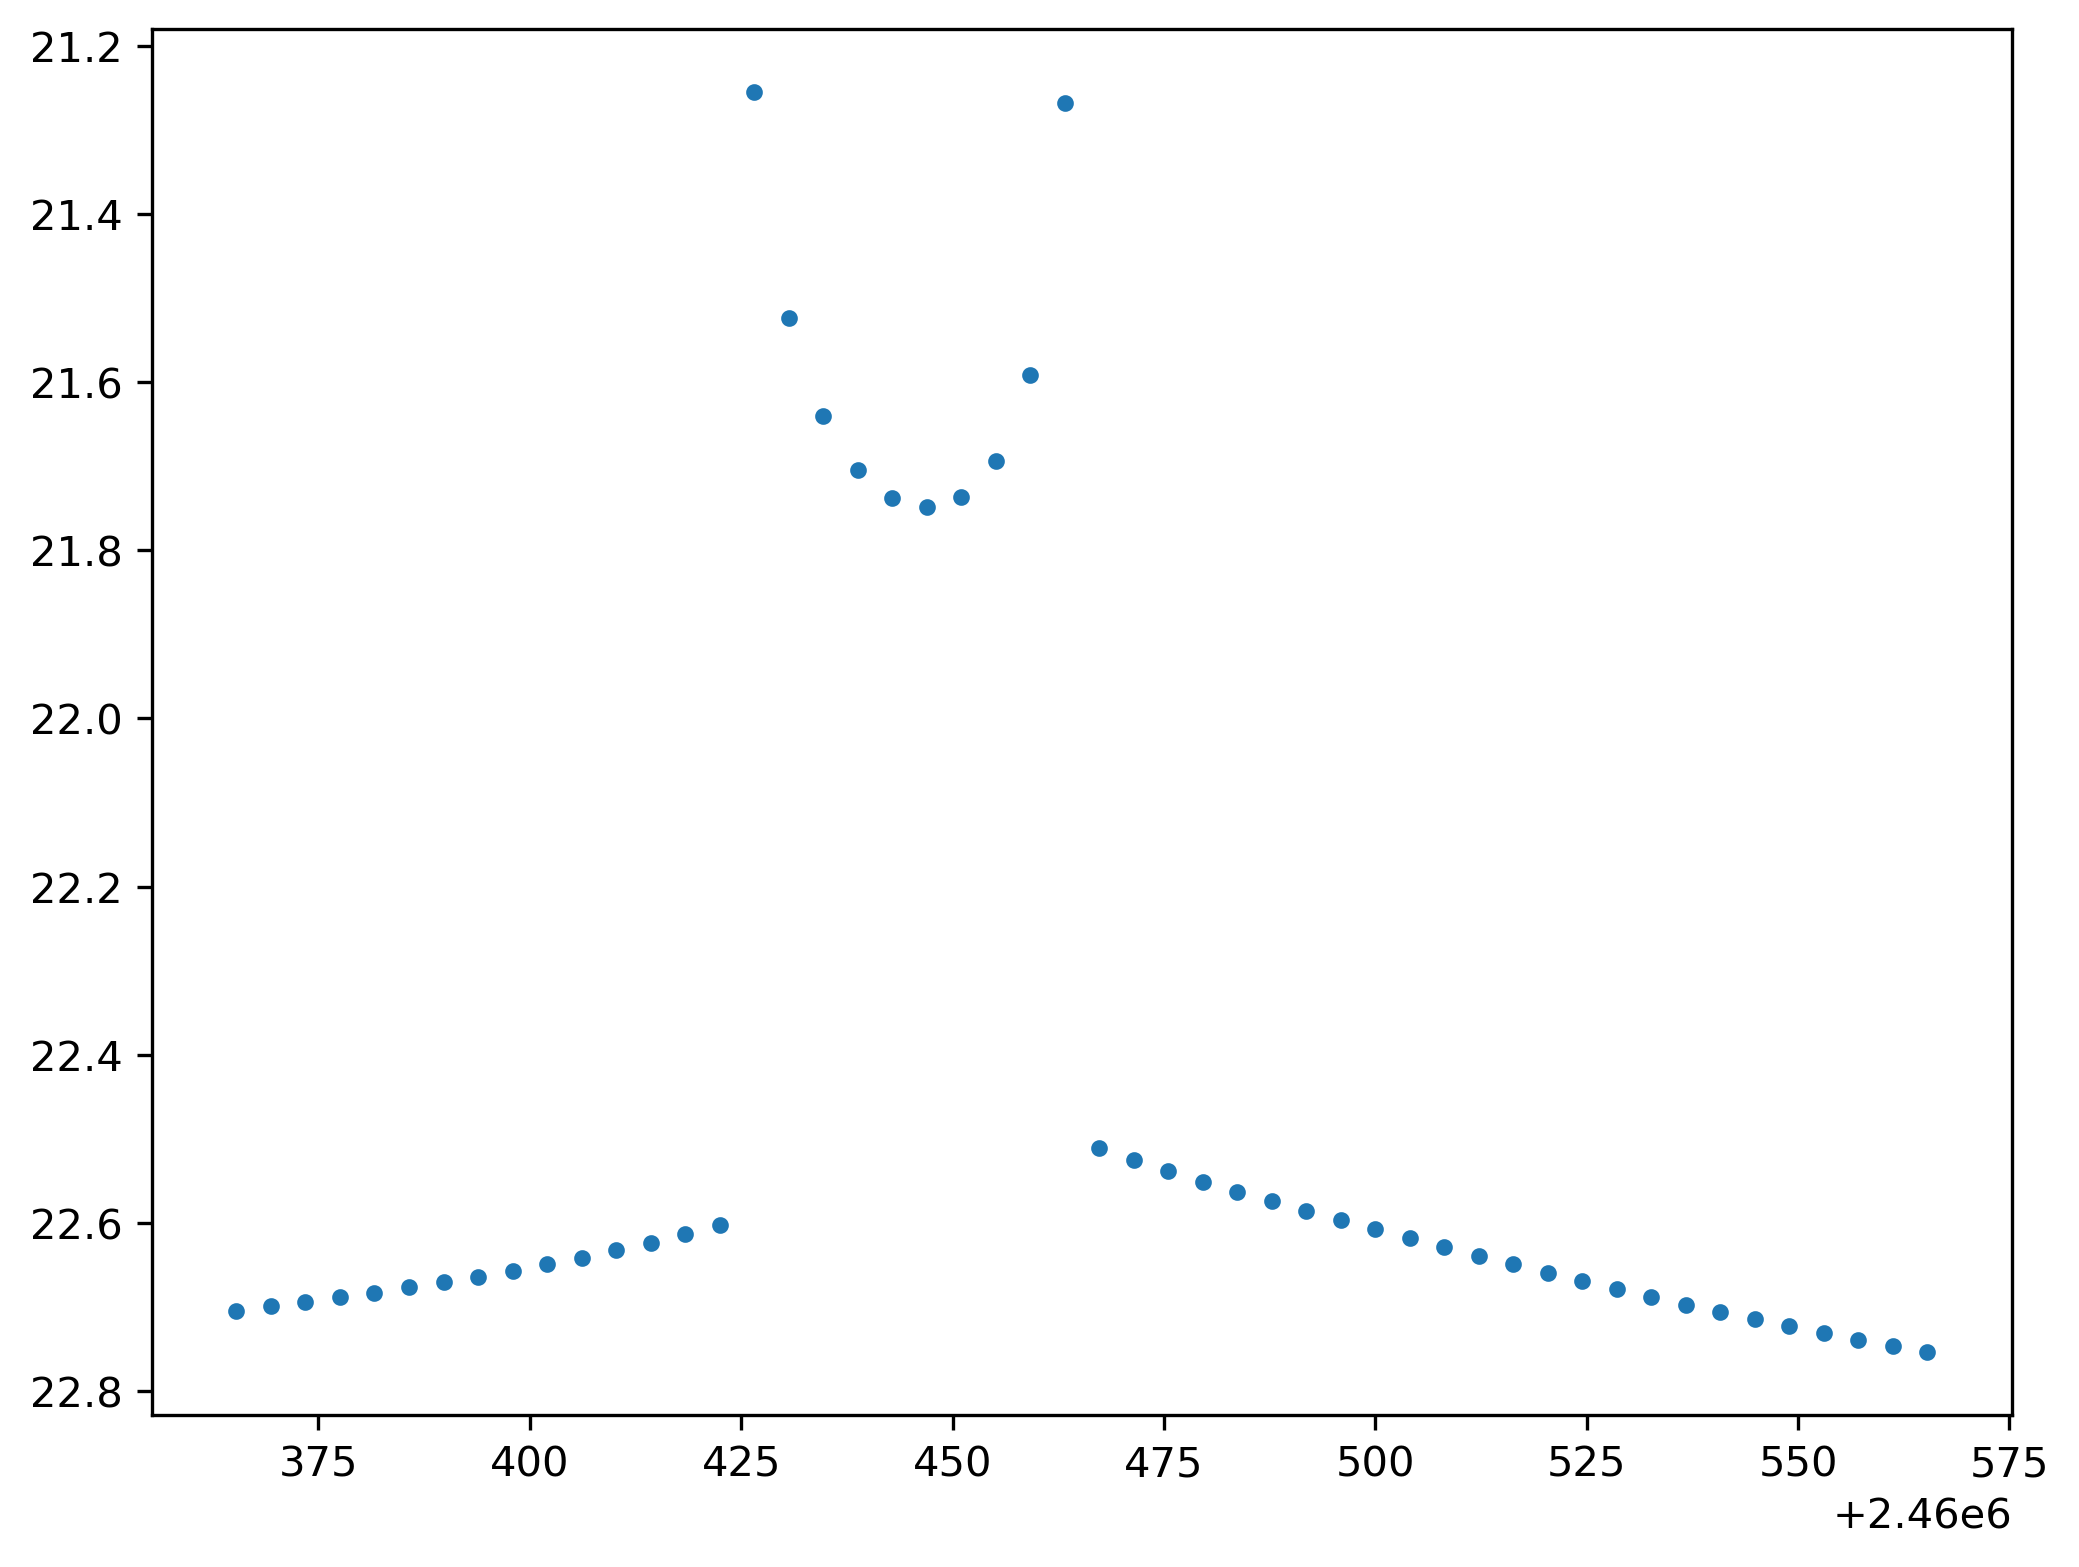

In [70]:
plt.figure(figsize=(8,6),dpi=300)
# for telo in perfect_model.event.telescopes:
plt.plot(epochs['i'], lighcurves[0].lightcurve['mag'],marker='.',ls='')
plt.gca().invert_yaxis()